In [ ]:
# # Gõ dòng này vào cell đầu tiên và bấm Run (Shift + Enter)
# get_ipython().run_line_magic('run', '../_setup.py')

In [2]:
import calendar

from coreforecast.scalers import boxcox, boxcox_lambda
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from pathlib import Path 
from IPython.display import display

In [3]:
BASE_DIR = Path.cwd().parent.parent
DATA_DIR = BASE_DIR / "data"
print(DATA_DIR)

d:\Documents\GitHub\-Time-Series-Analysis-and-Forecasting-methods-\data


### 1. Consider the GDP information in global_economy. Plot the GDP per capita for each country over time. Which country has the highest GDP per capita? How has this changed over time?

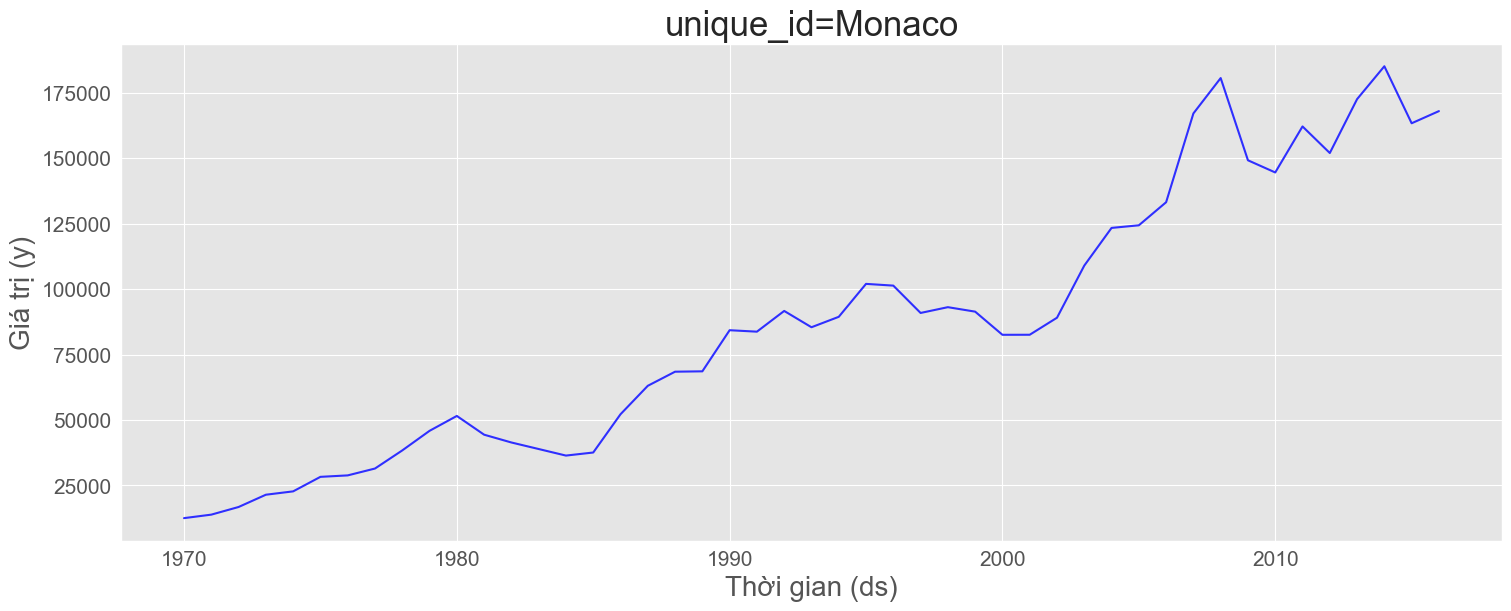

In [29]:
global_economy = (
    pd.read_csv(DATA_DIR / 'global_economy.csv')
    .assign(y = lambda x: x['GDP']/x['Population'])
    )

# because there are too many countries in this dataset. So, I suggests you shouldn't run this code.
# countries = global_economy['unique_id'].unique()

# for country in countries:
#     print(f"--- Đang hiển thị visual cho: {country} ---")

#     # Bước quan trọng để lọc từng origin
#     ddf_filtered = global_economy.query("unique_id == @country")
    
#     fig = plot_series(
#         df = df_filtered, 
#         id_col = "unique_id", 
#         time_col = "ds",
#         target_col = "y",
#         engine = "matplotlib"
#     )
#     for ax in fig.axes:
#                 ax.set_xlabel("Thời gian (ds)")
#                 ax.set_ylabel("Giá trị (y)")
#     # Hiển thị
#     display(fig)

# the highest GDP per-capita
global_economy.sort_values(by = 'y', ascending= False).head(1)
df_monaco = global_economy[global_economy['unique_id'] == 'Monaco']
fig = plot_series(df_monaco)
for ax in fig.axes:
    ax.set_xlabel("Thời gian (ds)")
    ax.set_ylabel("Giá trị (y)")
display(fig)

### 2. For each of the following series, make a graph of the data. If transforming seems appropriate, do so and describe the effect.

- United States GDP from `global_economy`.
- Slaughter of Victorian “Bulls, bullocks and steers” in `aus_livestock`.
- Victorian Electricity Demand from `vic_elec`.
- Gas production from `aus_production`.

### 3. Why is a Box-Cox transformation unhelpful for the canadian_gas data?

### 4. What Box-Cox transformation would you select for your retail data (from Exercise 7 in Section 2.10)?

### 5. For the following series, find an appropriate Box-Cox transformation in order to stabilise the variance. Tobacco from `aus_production`, Economy class passengers between Melbourne and Sydney from `ansett`, and Pedestrian counts at Southern Cross Station from `pedestrian`.

### 6. Show that a $3×5$ MA is equivalent to a 7-term weighted moving average with weights of 0.067, 0.133, 0.200, 0.200, 0.200, 0.133, and 0.067.

### 7. Consider the last five years of the Gas data from 'aus_production'.

gas = aus_production.loc[lambda x: x["unique_id"] == "Gas"].tail(5 * 4)

- Plot the time series. Can you identify seasonal fluctuations and/or a trend-cycle?
- Use seasonal_decompose with model='multiplicative' to calculate the trend-cycle and seasonal indices.
- Do the results support the graphical interpretation from part a?
- Compute and plot the seasonally adjusted data.
- Change one observation to be an outlier (e.g., add 300 to one observation), and recompute the seasonally adjusted data. What is the effect of the outlier?
- Does it make any difference if the outlier is near the end rather than in the middle of the time series?

### 8. Recall your retail time series data (from Exercise 7 in Section 2.10). Decompose the series using the MSTL method. Does it reveal any outliers, or unusual features that you had not noticed previously?

### 9. Figures 3.15 and 3.16 show the result of decomposing the number of persons in the civilian labour force in Australia each month from February 1978 to August 1995.

- Write about 3–5 sentences describing the results of the decomposition. Pay particular attention to the scales of the graphs in making your interpretation.
- Is the recession of 1991/1992 visible in the estimated components?

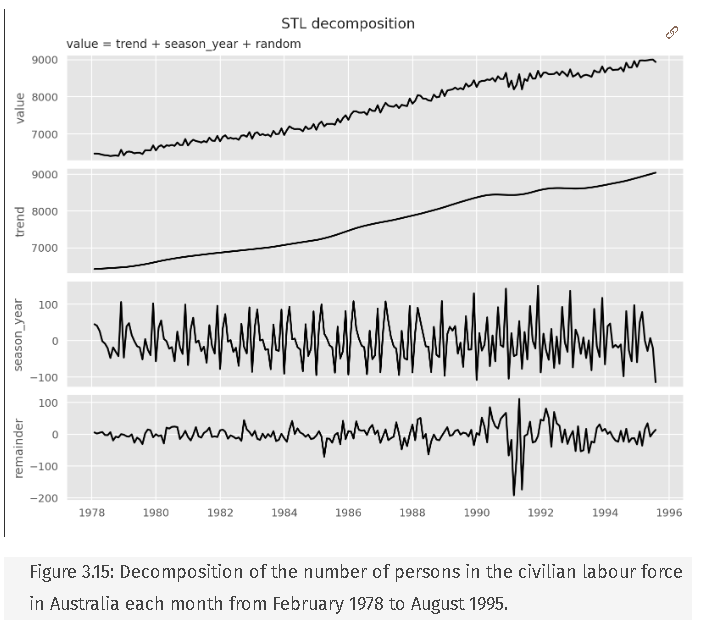

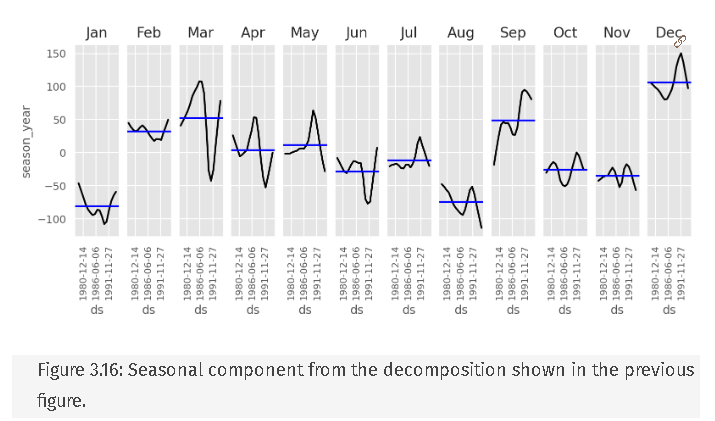


### 10. This exercise uses the canadian_gas data (monthly Canadian gas production in billions of cubic metres, January 1960 – February 2005).
- Plot the data using to look at the effect of the changing seasonality over time.1
- Do an STL decomposition of the data using STL().
- How does the seasonal shape change over time? [Hint: Try plotting the seasonal component.]
- Can you produce a plausible seasonally adjusted series?